In [1]:
from pathlib import Path
import itertools
import re
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import revpref as rp
from matplotlib.colors import to_rgba
from scipy import stats
from scipy.stats import spearmanr, ttest_ind, ttest_rel

PROJECT_DIR = Path.cwd()
RAW_DIR = PROJECT_DIR / "Raw Data"
RESULTS_DIR = PROJECT_DIR / "Results"
RESULTS_DIR.mkdir(exist_ok=True)

df_1 = pd.read_excel(next(RAW_DIR.glob("decision Political.xlsx")))
df_2 = pd.read_excel(next(RAW_DIR.glob("questionnaire Political.xlsx")))
df = df_1.merge(df_2, on="Prolific ID", how="inner")


## Overall

### Task share

In [2]:
def get_values1(row, prefix):
    cols = [f'{prefix} {i}' for i in range(1, 23)]
    return row[cols].values
def get_values2(row, prefix):
    cols = [f'{prefix} {i}' for i in range(23, 45)]
    return row[cols].values
def get_values3(row, prefix):
    cols = [f'{prefix} {i}' for i in range(45, 67)]
    return row[cols].values
def get_values4(row, prefix):
    cols = [f'{prefix} {i}' for i in range(67, 89)]
    return row[cols].values
df['px1'] = df.apply(lambda row: get_values1(row, 'X Revenue'), axis=1)
df['py1'] = df.apply(lambda row: get_values1(row, 'Y Revenue'), axis=1)
df['task_x1'] = df.apply(lambda row: get_values1(row, 'X Task'), axis=1)
df['task_y1'] = df.apply(lambda row: get_values1(row, 'Y Task'), axis=1)
df['qx1']=df['px1']* df['task_x1']
df['qy1']=df['py1']* df['task_y1']
df['px2'] = df.apply(lambda row: get_values2(row, 'X Revenue'), axis=1)
df['py2'] = df.apply(lambda row: get_values2(row, 'Y Revenue'), axis=1)
df['task_x2'] = df.apply(lambda row: get_values2(row, 'X Task'), axis=1)
df['task_y2'] = df.apply(lambda row: get_values2(row, 'Y Task'), axis=1)
df['qx2']=df['px2']* df['task_x2']
df['qy2']=df['py2']* df['task_y2']
df['px3'] = df.apply(lambda row: get_values3(row, 'X Revenue'), axis=1)
df['py3'] = df.apply(lambda row: get_values3(row, 'Y Revenue'), axis=1)
df['task_x3'] = df.apply(lambda row: get_values3(row, 'X Task'), axis=1)
df['task_y3'] = df.apply(lambda row: get_values3(row, 'Y Task'), axis=1)
df['qx3']=df['px3']* df['task_x3']
df['qy3']=df['py3']* df['task_y3']
df['px4'] = df.apply(lambda row: get_values4(row, 'X Revenue'), axis=1)
df['py4'] = df.apply(lambda row: get_values4(row, 'Y Revenue'), axis=1)
df['task_x4'] = df.apply(lambda row: get_values4(row, 'X Task'), axis=1)
df['task_y4'] = df.apply(lambda row: get_values4(row, 'Y Task'), axis=1)
df['qx4']=df['px4']* df['task_x4']
df['qy4']=df['py4']* df['task_y4']
df['task_share1'] = df['task_y1'].apply(
    lambda x: np.nanmean(x) if x is not None and len(x) else np.nan
)
df['task_share2'] = df['task_y2'].apply(
    lambda x: np.nanmean(x) if x is not None and len(x) else np.nan
)
df['task_share3'] = df['task_y3'].apply(
    lambda x: np.nanmean(x) if x is not None and len(x) else np.nan
)
df['task_share4'] = df['task_y4'].apply(
    lambda x: np.nanmean(x) if x is not None and len(x) else np.nan
)
df[['task_share1','task_share2','task_share3','task_share4']].describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
task_share1,299.0,49.577,3.273,9.045,48.977,50.000,50.591,59.227
task_share2,299.0,45.778,9.970,0.000,45.455,49.273,50.091,75.500
task_share3,299.0,44.530,12.823,0.000,42.977,49.227,50.250,68.182
task_share4,299.0,43.052,14.273,0.000,39.727,48.818,50.000,77.273


In [3]:
results = []
cols = ['task_share1', 'task_share2', 'task_share3', 'task_share4']
for col1, col2 in combinations(cols, 2):
    paired = df[[col1, col2]].dropna()
    x, y = paired[col1], paired[col2]
    n = len(paired)
    diff = x - y
    mean_diff = diff.mean()
    se_diff = diff.std(ddof=1) / np.sqrt(n)
    # paired t-test
    t_stat, p_value = stats.ttest_rel(x, y)
    # 95% CI
    t_crit = stats.t.ppf(0.975, df=n - 1)
    ci_lower = mean_diff - t_crit * se_diff
    ci_upper = mean_diff + t_crit * se_diff
    # ---- Bayes factor (JZS, Cauchy prior r = 0.707) ----
    bf10 = float(pg.bayesfactor_ttest(t_stat, nx=n, paired=True))
    bf01 = 1 / bf10   # BF01: Evidence for the null hypothesis of no difference
    results.append({
        'pair': f'{col1} vs {col2}',
        'n': n,
        'mean_diff': mean_diff,
        't_stat': t_stat,
        'p_value': p_value,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'BF10': bf10,
        'BF01': bf01
    })
results_df = pd.DataFrame(results)
print(results_df.round(3))


                         pair    n  mean_diff  t_stat  p_value  ci_lower  \
0  task_share1 vs task_share2  299      3.799   6.849    0.000     2.707   
1  task_share1 vs task_share3  299      5.047   6.767    0.000     3.579   
2  task_share1 vs task_share4  299      6.524   8.084    0.000     4.936   
3  task_share2 vs task_share3  299      1.248   1.703    0.090    -0.194   
4  task_share2 vs task_share4  299      2.725   4.156    0.000     1.435   
5  task_share3 vs task_share4  299      1.478   2.908    0.004     0.478   

   ci_upper          BF10   BF01  
0     4.891  1.542522e+08  0.000  
1     6.514  9.539658e+07  0.000  
2     8.112  3.405952e+11  0.000  
3     2.689  2.710000e-01  3.691  
4     4.016  2.658170e+02  0.004  
5     2.478  4.031000e+00  0.248  


### Fig.4(b)

Paired t-test results:
$H_{in}$-$H_{in}$ vs $H_{in}$-$H_{out}$: t=6.849, p=0.000 ***
$H_{in}$-$H_{in}$ vs $H_{in}$-$AI_{in}$: t=6.767, p=0.000 ***
$H_{in}$-$H_{in}$ vs $H_{in}$-$AI_{out}$: t=8.084, p=0.000 ***
$H_{in}$-$H_{out}$ vs $H_{in}$-$AI_{in}$: t=1.703, p=0.090 
$H_{in}$-$H_{out}$ vs $H_{in}$-$AI_{out}$: t=4.156, p=0.000 ***
$H_{in}$-$AI_{in}$ vs $H_{in}$-$AI_{out}$: t=2.908, p=0.004 **


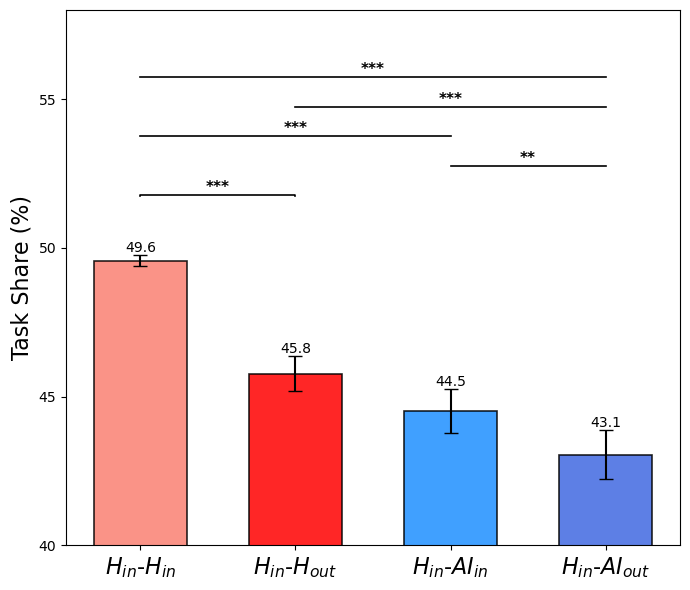

In [4]:
# Prepare data
variables = ['task_share1', 'task_share2', 'task_share3', 'task_share4']
labels = [r'$H_{in}$-$H_{in}$', r'$H_{in}$-$H_{out}$', r'$H_{in}$-$AI_{in}$', r'$H_{in}$-$AI_{out}$']
colors = ['salmon', 'red', 'dodgerblue', 'royalblue']
# Compute means and standard errors
means = [df[var].mean() for var in variables]
sems = [df[var].sem() for var in variables]
# Run paired t-tests and flag significance
def get_significance(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return ''
# Store significant pairwise comparisons
significant_pairs = []
print("=" * 60)
print("Paired t-test results:")
print("=" * 60)
for i, j in combinations(range(4), 2):
    data1 = df[variables[i]].dropna()
    data2 = df[variables[j]].dropna()
    t_stat, p_value = stats.ttest_rel(data1, data2, nan_policy='omit')
    sig = get_significance(p_value)
    print(f"{labels[i]} vs {labels[j]}: t={t_stat:.3f}, p={p_value:.3f} {sig}")
    if sig:  # Keep significant comparisons only
        significant_pairs.append((i, j, sig, p_value))
print("=" * 60)
# Create figure
fig, ax = plt.subplots(figsize=(7, 6))
# Draw the bar chart
x_pos = np.arange(len(variables))
bars = ax.bar(x_pos, means, yerr=sems, capsize=5, color=colors, 
              edgecolor='black', linewidth=1.2, alpha=0.85, width=0.6)
# Set x-axis labels
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=16)
ax.set_ylabel('Task Share (%)', fontsize=16)
# Define a helper for significance brackets
def add_significance_line(ax, x1, x2, y, sig, h=0.01, lw=1.2):
    """Add a significance bracket between two bars"""
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c='black')
    ax.text((x1+x2)/2, y+h, sig, ha='center', va='bottom', fontsize=11, fontweight='bold')
# Set the initial bracket height
max_height = max([m + s for m, s in zip(means, sems)])
y_offset = max_height * 0.04
# Sort brackets by distance so shorter brackets appear lower
significant_pairs_sorted = sorted(significant_pairs, key=lambda x: x[1] - x[0])
# Draw significance brackets
current_y = max_height + y_offset
for i, j, sig, p_val in significant_pairs_sorted:
    add_significance_line(ax, x_pos[i], x_pos[j], current_y, sig)
    current_y += max_height * 0.02
# Set y-axis limits
ax.set_ylim(40, 58)
# Set y-axis limits
ax.set_yticks([40,45, 50, 55])
# Add grid lines
ax.set_axisbelow(True)
# Add mean labels above bars
for i, (bar, mean) in enumerate(zip(bars, means)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + sems[i], 
            f'{mean:.1f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "Fig.4(b).pdf", dpi=300, bbox_inches='tight')
plt.show()


### Extended Data Fig.6(b)

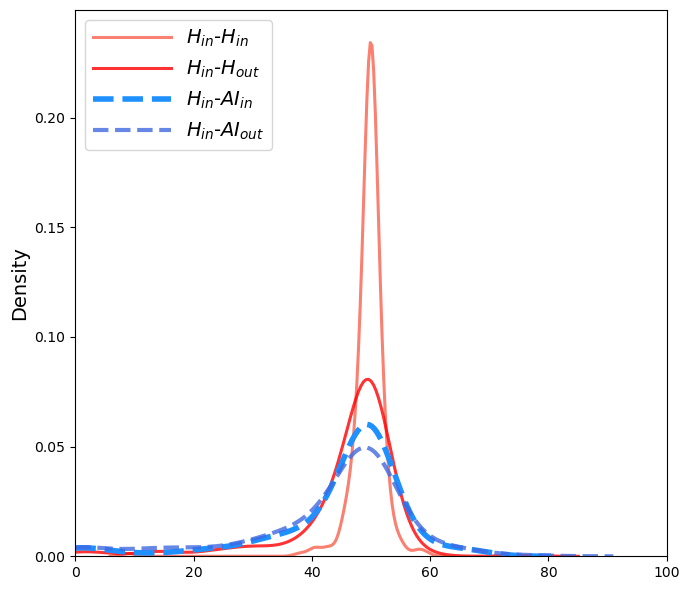

In [5]:
labels = [r'$H_{in}$-$H_{in}$', r'$H_{in}$-$H_{out}$', r'$H_{in}$-$AI_{in}$', r'$H_{in}$-$AI_{out}$']
colors = ['salmon', 'red', 'dodgerblue', 'royalblue']
cols = ['task_share1','task_share2','task_share3','task_share4']
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
linewidths = [2.2, 2.2,4, 3]
linestyles = ['-', '-', '--', '--']
for c, lab, col, lw, ls, alpha in zip(cols, labels, colors, linewidths, linestyles, [1, 0.8, 1, 0.8]):
    x = pd.to_numeric(df[c], errors='coerce').dropna()
    sns.kdeplot(
        x=x, ax=ax,
        label=lab, color=col,
        lw=lw, linestyle=ls,
        fill=False, alpha=alpha,
        clip=(0, 100)
    )
ax.set_xlabel(None)
ax.set_ylabel('Density', fontsize=14)
ax.set_xlim(0, 100)
ax.set_ylim(0, 0.249)
ax.legend(loc='upper left', fontsize=14,handlelength=4)
ax.grid(False)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "Extended Data Fig.6(b).pdf")
plt.show()


### Minimal vs. Political

In [6]:
# Summary statistics
n1, m1, s1 = 299, 47.89746, 6.45436
n2, m2, s2 = 297, 45.77774, 9.9699
diff = m1 - m2
t_stat, p_val = stats.ttest_ind_from_stats(m1, s1, n1, m2, s2, n2,
                                           equal_var=True)
dof = n1 + n2 - 2
sp2 = ((n1-1)*s1**2 + (n2-1)*s2**2) / dof
se = np.sqrt(sp2 * (1/n1 + 1/n2))
t_crit = stats.t.ppf(0.975, dof)
ci = (diff - t_crit*se, diff + t_crit*se)
print(f"Pooled: diff={diff:.3f}, t={t_stat:.3f}, dof={dof}, p={p_val:.4f}")
print(f"95% CI: ({ci[0]:.3f}, {ci[1]:.3f})")
t_w, p_w = stats.ttest_ind_from_stats(m1, s1, n1, m2, s2, n2,
                                      equal_var=False)
se_w = np.sqrt(s1**2/n1 + s2**2/n2)
dof_w = (s1**2/n1 + s2**2/n2)**2 / ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))
t_crit_w = stats.t.ppf(0.975, dof_w)
ci_w = (diff - t_crit_w*se_w, diff + t_crit_w*se_w)
print(f"Welch:  diff={diff:.3f}, t={t_w:.3f}, dof={dof_w:.1f}, p={p_w:.4f}")
print(f"95% CI: ({ci_w[0]:.3f}, {ci_w[1]:.3f})")


Pooled: diff=2.120, t=3.083, dof=594, p=0.0021
95% CI: (0.769, 3.470)
Welch:  diff=2.120, t=3.079, dof=506.6, p=0.0022
95% CI: (0.767, 3.472)


## Payoff-Maximizing Behavior

### Loss Comparsion

In [7]:
for i in range(1, 89):
    x_rev = f"X Revenue {i}"
    y_rev = f"Y Revenue {i}"
    x_task = f"X Task {i}"
    y_task = f"Y Task {i}"
    df[f"Revenue Max {i}"] = df[[x_rev, y_rev]].max(axis=1) * 100
    df[f"Revenue Min {i}"] = df[[x_rev, y_rev]].min(axis=1) * 100
    # Revenue i：X Revenue i * X Task i + Y Revenue i * Y Task i
    df[f"Revenue {i}"] = df[x_rev].mul(df[x_task]) + df[y_rev].mul(df[y_task])
cols = []
for i in range(1, 89):
    rev_max = f"Revenue Max {i}"
    rev_min = f"Revenue Min {i}"
    rev_i   = f"Revenue {i}"
    denom = df[rev_max] - df[rev_min]
    term = (df[rev_max] - df[rev_i]) / denom
    # Avoid division-by-zero errors
    term = term.where(denom.ne(0), np.nan)
    col = f"ratio {i}"
    df[col] = term
    cols.append(col)
df["loss_ratio_1"]   = df[[f"ratio {i}" for i in range(1, 23)]].mean(axis=1, skipna=True)
df["loss_ratio_2"]  = df[[f"ratio {i}" for i in range(23, 45)]].mean(axis=1, skipna=True)
df["loss_ratio_3"]  = df[[f"ratio {i}" for i in range(45, 67)]].mean(axis=1, skipna=True)
df["loss_ratio_4"]  = df[[f"ratio {i}" for i in range(67, 89)]].mean(axis=1, skipna=True)
df[["loss_ratio_1","loss_ratio_2","loss_ratio_3","loss_ratio_4"]].describe().T.round(3)


/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65968/1216949976.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"Revenue Max {i}"] = df[[x_rev, y_rev]].max(axis=1) * 100
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65968/1216949976.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"Revenue Min {i}"] = df[[x_rev, y_rev]].min(axis=1) * 100
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65968/1216949976.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the

,count,mean,std,min,25%,50%,75%,max
loss_ratio_1,299.0,0.211,0.165,0.0,0.073,0.210,0.312,0.831
loss_ratio_2,299.0,0.232,0.170,0.0,0.099,0.230,0.345,0.807
loss_ratio_3,299.0,0.228,0.168,0.0,0.094,0.218,0.330,0.811
loss_ratio_4,299.0,0.232,0.166,0.0,0.100,0.222,0.339,0.820


In [8]:
# Define base indices
# Define base indices
group_A = [2, 8, 10, 12, 13, 14, 16, 18, 20, 22] 
group_B = [1, 3, 4, 6, 9, 11, 15, 17, 19, 21]   
# Define offsets
offsets = [0, 22, 44, 66]
# Create summary columns
for idx, offset in enumerate(offsets, start=1):
    # Group A
    cols_A = [f"ratio {i + offset}" for i in group_A]
    df[f"ratio_sum_A{idx}"] = df[cols_A].mean(axis=1, skipna=True)
    # Group B
    cols_B = [f"ratio {i + offset}" for i in group_B]
    df[f"ratio_sum_B{idx}"] = df[cols_B].mean(axis=1, skipna=True)

/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65968/662564063.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"ratio_sum_A{idx}"] = df[cols_A].mean(axis=1, skipna=True)
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65968/662564063.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"ratio_sum_B{idx}"] = df[cols_B].mean(axis=1, skipna=True)
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65968/662564063.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually t

### Extended Data Fig.4(b)

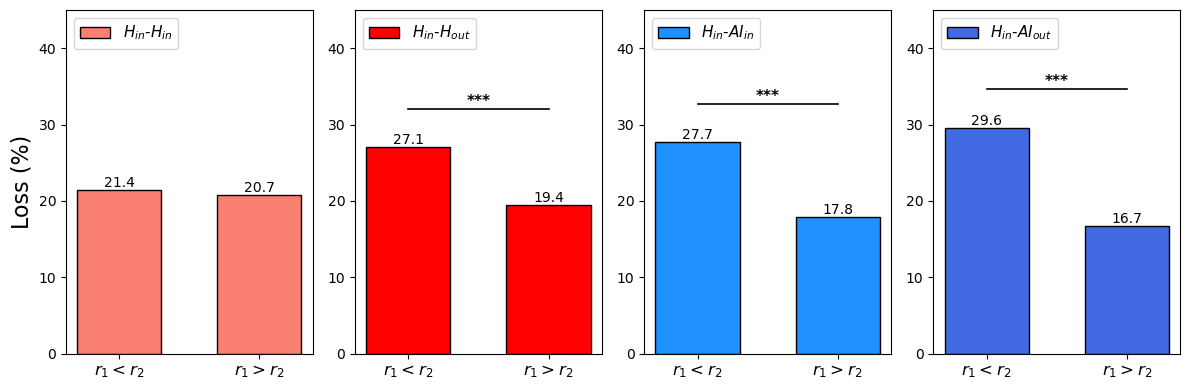

ratio_sum_A1 vs ratio_sum_B1: t = 1.775, p = 0.07697
ratio_sum_A2 vs ratio_sum_B2: t = 6.749, p = 7.744e-11
ratio_sum_A3 vs ratio_sum_B3: t = 6.820, p = 5.063e-11
ratio_sum_A4 vs ratio_sum_B4: t = 7.894, p = 5.638e-14


In [9]:
def add_significance_line(ax, x1, x2, y, sig, h=0.1, lw=1.2):
    """Add a significance bracket between two bars"""
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c='black')
    ax.text((x1+x2)/2, y+h, sig, ha='center', va='bottom',
            fontsize=11, fontweight='bold')
labels = [r'$H_{in}$-$H_{in}$', r'$H_{in}$-$H_{out}$', r'$H_{in}$-$AI_{in}$', r'$H_{in}$-$AI_{out}$']
colors = ['salmon', 'red', 'dodgerblue', 'royalblue']
bar_labels_list = [
    [r'$r_1<r_2$', r'$r_1>r_2$'],
    [r'$r_1<r_2$', r'$r_1>r_2$'],
    [r'$r_1<r_2$', r'$r_1>r_2$'],
    [r'$r_1<r_2$', r'$r_1>r_2$'],
]
# Compute means
means_A = [df[f"ratio_sum_A{i}"].mean()*100 for i in range(1, 5)]
means_B = [df[f"ratio_sum_B{i}"].mean()*100 for i in range(1, 5)]
# Create subplots
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
axes = axes.flatten()
ttest_results = []
for idx in range(4):
    ax = axes[idx]
    colA = f"ratio_sum_A{idx+1}"
    colB = f"ratio_sum_B{idx+1}"
    # Run paired t-tests after dropping missing values
    a_vals = df[colA]
    b_vals = df[colB]
    paired = np.vstack([a_vals, b_vals]).T
    paired = paired[~np.isnan(paired).any(axis=1)]
    a_clean = paired[:, 0]
    b_clean = paired[:, 1]
    t_stat, p_val = ttest_rel(a_clean, b_clean)
    ttest_results.append((colA, colB, t_stat, p_val))
    # Bar heights
    values = [means_A[idx], means_B[idx]]
    x_pos = [0, 1]
    # Draw bars and add legend labels
    bars = ax.bar(x_pos, values, color=[colors[idx], colors[idx]],
                  edgecolor='black', width=0.6, label=labels[idx])
    # Set labels without titles
    ax.set_xticks(x_pos)
    ax.set_xticklabels(bar_labels_list[idx], fontsize=12)
    if idx == 0:
        ax.set_ylabel('Loss (%)', fontsize=16)
    # Add legend
    ax.legend(loc='upper left', fontsize=11, frameon=True)
    # Show values on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10)
    # Create significance labels from p-values
    sig = ""
    if p_val < 0.001:
        sig = '***'
    elif p_val < 0.01:
        sig = '**'
    elif p_val < 0.05:
        sig = '*'
    # Draw brackets only for significant tests
    if sig:
        y = max(values) + 5  # Line position above the bars
        add_significance_line(ax, x_pos[0], x_pos[1], y, sig, h=0.02)
    ax.set_axisbelow(True)
    ax.set_ylim(0, 45)
    ax.set_yticks(np.arange(0, 50, 10))
plt.tight_layout()
plt.savefig(RESULTS_DIR / "Extended Data Fig.4(b).pdf", dpi=300, bbox_inches='tight')
plt.show()
# Print paired t-test results
for colA, colB, t_stat, p_val in ttest_results:
    print(f"{colA} vs {colB}: t = {t_stat:.3f}, p = {p_val:.4g}")


## Decision-Making Quality

### Compute CCEI

In [10]:
# Combine px1 and py1 into a 2x22 array
# Combine px1 and py1 into arrays and concatenate
df['p1'] = df.apply(lambda row: 
    np.array([row['px1'], row['py1']]) , axis=1)
df['q1'] = df.apply(lambda row: 
    np.array([row['qx1'], row['qy1']]) , axis=1)
df['p2'] = df.apply(lambda row: 
    np.array([row['px2'], row['py2']]) , axis=1)
df['q2'] = df.apply(lambda row: 
    np.array([row['qx2'], row['qy2']]) , axis=1)
df['p3'] = df.apply(lambda row: 
    np.array([row['px3'], row['py3']]) , axis=1)
df['q3'] = df.apply(lambda row: 
    np.array([row['qx3'], row['qy3']]) , axis=1)
df['p4'] = df.apply(lambda row: 
    np.array([row['px4'], row['py4']]) , axis=1)
df['q4'] = df.apply(lambda row: 
    np.array([row['qx4'], row['qy4']]) , axis=1)


/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65968/494885882.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['p1'] = df.apply(lambda row:
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65968/494885882.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['q1'] = df.apply(lambda row:
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65968/494885882.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor pe

/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65968/494885882.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['q2'] = df.apply(lambda row:
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65968/494885882.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['p3'] = df.apply(lambda row:
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65968/494885882.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor 

In [11]:
def compute_ccei(p, q, *, invert_p=True):
    """
    Compute the CCEI for given p and q.
    Parameters
    ----------
    p, q : array-like
        Accept numpy arrays, lists, pandas Series, or ndarrays stored in cells.
        Accept common shapes and coerce them to 2D.
    invert_p : bool
        Whether to transform p as 1/p.
    Returns
    -------
    float
        CCEI value; returns np.nan on failure.
    """
    try:
        p = np.asarray(p)
        q = np.asarray(q)
        if invert_p:
            p = 1.0 / p
        # Transpose to keep the original calculation convention
        p = p.T
        q = q.T
        # revpref typically expects a 2D goods-by-observations structure
        if p.ndim == 1:
            p = p.reshape(-1, 1)
        if q.ndim == 1:
            q = q.reshape(-1, 1)
        pref = rp.RevealedPreference(p, q)
        return pref.ccei()
    except Exception as e:
        print(f"Error while computing CCEI: {e}")
        return np.nan
df["ccei1"] = df.apply(lambda r: compute_ccei(r["p1"], r["q1"]), axis=1)
df["ccei2"] = df.apply(lambda r: compute_ccei(r["p2"], r["q2"]), axis=1)
df["ccei3"] = df.apply(lambda r: compute_ccei(r["p3"], r["q3"]), axis=1)
df["ccei4"] = df.apply(lambda r: compute_ccei(r["p4"], r["q4"]), axis=1)
df[["ccei1", "ccei2", "ccei3", "ccei4"]].describe().T.round(3)

/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65968/2371764557.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ccei1"] = df.apply(lambda r: compute_ccei(r["p1"], r["q1"]), axis=1)


/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65968/2371764557.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ccei2"] = df.apply(lambda r: compute_ccei(r["p2"], r["q2"]), axis=1)


/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65968/2371764557.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ccei3"] = df.apply(lambda r: compute_ccei(r["p3"], r["q3"]), axis=1)


/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65968/2371764557.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ccei4"] = df.apply(lambda r: compute_ccei(r["p4"], r["q4"]), axis=1)


,count,mean,std,min,25%,50%,75%,max
ccei1,299.0,0.968,0.106,0.288,0.999,1.0,1.0,1.0
ccei2,299.0,0.965,0.116,0.288,0.999,1.0,1.0,1.0
ccei3,299.0,0.963,0.119,0.288,0.997,1.0,1.0,1.0
ccei4,299.0,0.968,0.107,0.250,0.998,1.0,1.0,1.0


In [12]:
def simulate_ccei_for_row(df, row_idx, n_sim=1000, *, seed=None, invert_p=True):
    """
    For one row of df, simulate random q1 values
    compute CCEI n_sim times and return the mean.
    Parameters
    ----------
    df : DataFrame
    row_idx : Row index, either an integer position or a label.
    n_sim : Number of simulations.
    seed : Optional random seed.
    invert_p : Argument passed to compute_ccei.
    Returns
    -------
    mean_ccei : float
        Mean CCEI over n_sim simulations.
    all_ccei : ndarray
        Vector of CCEI values with length n_sim.
    """
    # Select the row
    row = df.loc[row_idx]
    # Extract p1 and q1
    p1 = np.asarray(row["p1"])
    q1 = np.asarray(row["q1"])
    rng = np.random.default_rng(seed)
    cceis = np.empty(n_sim, dtype=float)
    for i in range(n_sim):
        # Handle both 2x22 and 22x2 shapes
        if p1.shape == (2, 22):
            T = p1.shape[1]      # 22
            x = rng.uniform(0, 100, size=T)  # Uniform draw on [0, 100] with length 22
            random_q1 = np.empty_like(p1, dtype=float)
            # Each period： (x_t, 100-x_t) * (p1_good1_t, p1_good2_t)
            random_q1[0, :] = x * p1[0, :]
            random_q1[1, :] = (100 - x) * p1[1, :]
        elif p1.shape == (22, 2):
            T = p1.shape[0]      # 22
            x = rng.uniform(0, 100, size=T)
            random_q1 = np.empty_like(p1, dtype=float)
            random_q1[:, 0] = x * p1[:, 0]
            random_q1[:, 1] = (100 - x) * p1[:, 1]
        else:
            raise ValueError(f"Unsupported p1 shape: {p1.shape}; expected 2x22 or 22x2")
        # Pass simulated choices to the CCEI function
        cceis[i] = compute_ccei(p1, random_q1, invert_p=invert_p)
    return cceis.mean(), cceis
mean_ccei, all_cceis = simulate_ccei_for_row(df, row_idx=0, n_sim=1000, seed=123)
print("Mean simulated CCEI for this row under random q1:", mean_ccei)


Mean simulated CCEI for this row under random q1: 0.7126490436523776


### Extended Data Fig.2(c)

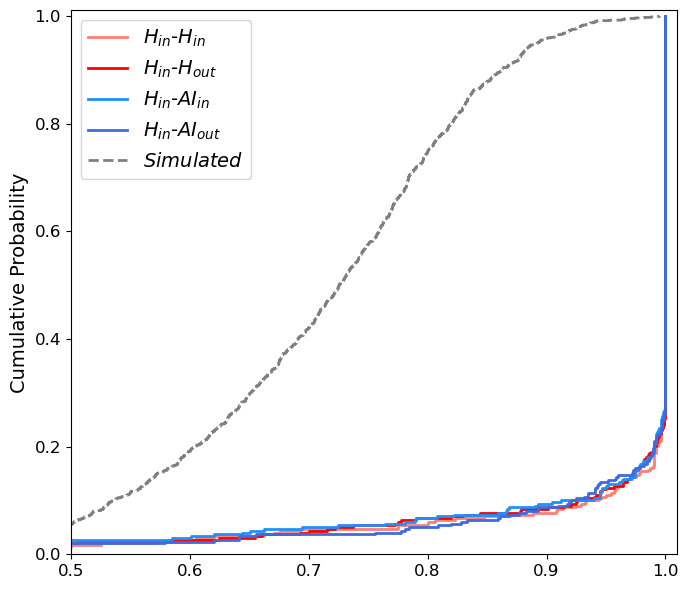

In [13]:
# Set labels and colors
labels = [r'$H_{in}$-$H_{in}$', r'$H_{in}$-$H_{out}$', r'$H_{in}$-$AI_{in}$', r'$H_{in}$-$AI_{out}$']
colors = ['salmon', 'red', 'dodgerblue', 'royalblue']
ccei_cols = ['ccei1', 'ccei2', 'ccei3', 'ccei4']
fig, ax = plt.subplots(figsize=(7, 6))
# Draw CDF curves
for col, label, color in zip(ccei_cols, labels, colors):
    data = df[col].dropna()
    sns.ecdfplot(data=data, ax=ax, label=label, color=color, linewidth=2)
sns.ecdfplot(
    data=all_cceis, ax=ax,
    label=r'$Simulated$', color='gray',
    linestyle='--', linewidth=2
)
# Set figure properties
ax.set_ylim(0, 1.01)
ax.set_xlabel(None)
ax.set_ylabel('Cumulative Probability', fontsize=14)
ax.legend(loc='upper left', fontsize=14)
ax.grid(False)
# Set tick-label font size
ax.tick_params(axis='both', labelsize=12)
ax.set_xlim(0.5, 1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "Extended Data Fig.2(c).pdf")
plt.show()


In [14]:
threshold = 0.9
prop_over_09 = (
    df[["ccei1", "ccei2", "ccei3","ccei4"]]  # Select CCEI columns
    .gt(threshold)                           
    .mean()                                
)
(prop_over_09 * 100).round(0)


ccei1    92.0
ccei2    92.0
ccei3    91.0
ccei4    91.0
dtype: float64

### Extended Data Fig.3(c)

In [15]:
for i in range(1, 5):
    # Compute ln_price_ratio
    def calc_ln_price_ratio(row, idx=i):
        px = row[f'px{idx}'].astype(float)
        py = row[f'py{idx}'].astype(float)
        # Replace zeros in py with a small value
        py = np.where(py == 0, 0.1, py)
        px = np.where(px == 0, 0.1, px)
        return np.log(px / py)
    df[f'ln_price_ratio{i}'] = df.apply(lambda row, idx=i: calc_ln_price_ratio(row, idx), axis=1)
    # Compute ln_q_ratio
    def calc_ln_q_ratio(row, idx=i):
        px = row[f'px{idx}'].astype(float)
        py = row[f'py{idx}'].astype(float)
        task_x = row[f'task_x{idx}'].astype(float)
        task_y = row[f'task_y{idx}'].astype(float)
        # Replace zero task values with 0.1
        task_x = np.where(task_x == 0, 0.1, task_x)
        task_y = np.where(task_y == 0, 0.1, task_y)
        # Apply the same zero adjustment to revenue
        px = np.where(px == 0, 0.1, px)
        py = np.where(py == 0, 0.1, py)
        qx = px * task_x
        qy = py * task_y
        return np.log(qx / qy)
    df[f'ln_q_ratio{i}'] = df.apply(lambda row, idx=i: calc_ln_q_ratio(row, idx), axis=1)
def calc_spearman_corr(row, idx):
    ln_price = row[f'ln_price_ratio{idx}']
    ln_q = row[f'ln_q_ratio{idx}']
    # Ensure array format
    ln_price = np.array(ln_price).astype(float)
    ln_q = np.array(ln_q).astype(float)
    # Handle possible nan or inf values
    mask = np.isfinite(ln_price) & np.isfinite(ln_q)
    if mask.sum() < 2:  # Require at least two valid observations
        return np.nan
    corr, _ = spearmanr(ln_price[mask], ln_q[mask])
    return corr
# Compute Spearman correlations across measures
for i in range(1, 5):
    df[f'spearman_corr{i}'] = df.apply(lambda row, idx=i: calc_spearman_corr(row, idx), axis=1)


/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65968/862406960.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'ln_price_ratio{i}'] = df.apply(lambda row, idx=i: calc_ln_price_ratio(row, idx), axis=1)
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65968/862406960.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'ln_q_ratio{i}'] = df.apply(lambda row, idx=i: calc_ln_q_ratio(row, idx), axis=1)
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65968/862406960.py:10: PerformanceWarni

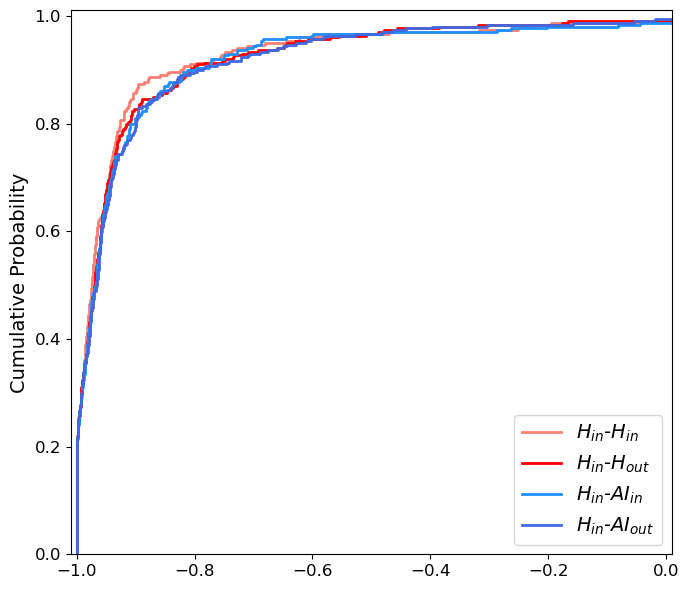

In [16]:
# Set labels and colors
labels = [r'$H_{in}$-$H_{in}$', r'$H_{in}$-$H_{out}$', r'$H_{in}$-$AI_{in}$', r'$H_{in}$-$AI_{out}$']
colors = ['salmon', 'red', 'dodgerblue', 'royalblue']
ccei_cols =  ['spearman_corr1', 'spearman_corr2', 'spearman_corr3', 'spearman_corr4']
fig, ax = plt.subplots(figsize=(7, 6))
# Draw CDF curves
for col, label, color in zip(ccei_cols, labels, colors):
    data = df[col].dropna()
    sns.ecdfplot(data=-data, ax=ax, label=label, color=color, linewidth=2)
# Set figure properties
ax.set_ylim(0, 1.01)
# Use double quotes for string labels
ax.set_xlabel(None)
ax.set_ylabel('Cumulative Probability', fontsize=14)
ax.legend(loc='lower right', fontsize=14)
ax.grid(False)
# Set tick-label font size
ax.tick_params(axis='both', labelsize=12)
ax.set_xlim(-1.01, 0.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "Extended Data Fig.3(c).pdf")
plt.show()


## Other-Other Allocation

In [17]:
parts = df["Answer 9"].astype(str).str.split("|", expand=True)
parts.columns = [f"Allocation {i}" for i in range(1, 9)]
df = df.join(parts.apply(pd.to_numeric, errors="coerce"))
df[["Allocation 1","Allocation 2","Allocation 3","Allocation 4","Allocation 5","Allocation 6","Allocation 7","Allocation 8"]].describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
Allocation 1,299.0,49.662,7.240,0.0,50.0,50.0,50.0,100.0
Allocation 2,299.0,50.338,7.240,0.0,50.0,50.0,50.0,100.0
Allocation 3,299.0,66.548,21.699,0.0,50.0,55.0,90.0,100.0
Allocation 4,299.0,33.452,21.699,0.0,10.0,45.0,50.0,100.0
Allocation 5,299.0,80.575,22.822,0.0,60.0,90.0,100.0,100.0
Allocation 6,299.0,19.425,22.822,0.0,0.0,10.0,40.0,100.0
Allocation 7,299.0,84.043,22.345,0.0,70.0,100.0,100.0,100.0
Allocation 8,299.0,15.957,22.345,0.0,0.0,0.0,30.0,100.0


In [18]:
df = df.rename(columns={
    "Allocation 2": "Allocation Human same",
    "Allocation 4": "Allocation Human different",
    "Allocation 6": "Allocation AI same",
    "Allocation 8": "Allocation AI different"
})


### Extended Data Fig.5(b)

Paired t-test results:
$H_{in}$-$H_{in}$ vs $H_{in}$-$H_{out}$: t=13.349, p=0.0000 ***
$H_{in}$-$H_{in}$ vs $H_{in}$-$AI_{in}$: t=23.896, p=0.0000 ***
$H_{in}$-$H_{in}$ vs $H_{in}$-$AI_{out}$: t=27.044, p=0.0000 ***
$H_{in}$-$H_{out}$ vs $H_{in}$-$AI_{in}$: t=9.374, p=0.0000 ***
$H_{in}$-$H_{out}$ vs $H_{in}$-$AI_{out}$: t=13.643, p=0.0000 ***
$H_{in}$-$AI_{in}$ vs $H_{in}$-$AI_{out}$: t=4.556, p=0.0000 ***


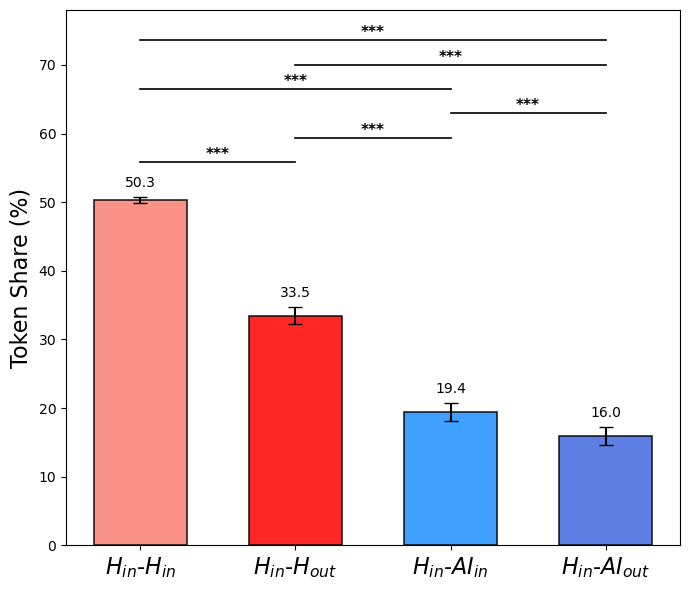

In [19]:
# ------------------ Prepare data -------------------
cols = ["Allocation Human same", "Allocation Human different", "Allocation AI same", "Allocation AI different"]
labels = [r'$H_{in}$-$H_{in}$', r'$H_{in}$-$H_{out}$', r'$H_{in}$-$AI_{in}$', r'$H_{in}$-$AI_{out}$']
colors = ['salmon', 'red', 'dodgerblue', 'royalblue']
# Compute means and standard errors
means = [df[var].mean() for var in cols]
sems = [df[var].sem() for var in cols]
def get_significance(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return ''
# Store significant pairwise comparisons
significant_pairs = []
print("=" * 60)
print("Paired t-test results:")
print("=" * 60)
for i, j in combinations(range(4), 2):
    data1 = df[cols[i]].dropna()
    data2 = df[cols[j]].dropna()
    t_stat, p_value = stats.ttest_rel(data1, data2, nan_policy='omit')
    sig = get_significance(p_value)
    print(f"{labels[i]} vs {labels[j]}: t={t_stat:.3f}, p={p_value:.4f} {sig}")
    if sig:  # Keep significant comparisons only
        significant_pairs.append((i, j, sig, p_value))
print("=" * 60)
# ------------------ Create figure -------------------
fig, ax = plt.subplots(figsize=(7, 6))
# Draw the bar chart
x_pos = np.arange(len(cols))
bars = ax.bar(x_pos, means, yerr=sems, capsize=5, color=colors, 
              edgecolor='black', linewidth=1.2, alpha=0.85, width=0.6)
# Set x-axis labels
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=16)
ax.set_ylabel('Token Share (%)', fontsize=16)
# Define a helper for significance brackets
def add_significance_line(ax, x1, x2, y, sig, h=0.01, lw=1.2):
    """Add a significance bracket between two bars"""
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c='black')
    ax.text((x1+x2)/2, y+h, sig, ha='center', va='bottom', fontsize=11, fontweight='bold')
# Set the initial bracket height
max_height = max([m + s for m, s in zip(means, sems)])
y_offset = max_height * 0.1
# Sort brackets by distance so shorter brackets appear lower
significant_pairs_sorted = sorted(significant_pairs, key=lambda x: x[1] - x[0])
# Draw significance brackets
current_y = max_height + y_offset
for i, j, sig, p_val in significant_pairs_sorted:
    add_significance_line(ax, x_pos[i], x_pos[j], current_y, sig)
    current_y += max_height * 0.07
# Set y-axis limits
ax.set_ylim(0, 78)
ax.set_yticks(np.arange(0, 78, 10))
# Add grid lines
ax.set_axisbelow(True)
# Add mean labels above bars
for i, (bar, mean) in enumerate(zip(bars, means)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + sems[i] + 1, 
            f'{mean:.1f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "Extended Data Fig.5(b).pdf", dpi=300, bbox_inches='tight')
plt.show()


## Individual Heterogeneity

In [20]:
# Use double brackets to select multiple columns
cols = ["task_share1", "task_share2", "task_share3","task_share4"]
data = df[cols].dropna()  # Drop missing values before F-tests
results = []
# ============ 1. Pairwise F-tests ============
for col1, col2 in combinations(cols, 2):
    x = data[col1]
    y = data[col2]
    var1, var2 = x.var(ddof=1), y.var(ddof=1)
    n1, n2 = len(x), len(y)
    # F-statistic with the larger variance in the numerator
    if var1 >= var2:
        F = var1 / var2
        dfn, dfd = n1 - 1, n2 - 1
    else:
        F = var2 / var1
        dfn, dfd = n2 - 1, n1 - 1
    # Two-sided p-value
    p_value = 2 * (1 - stats.f.cdf(F, dfn, dfd))
    p_value = min(p_value, 1.0)
    results.append({
        "Comparison": f"{col1} vs {col2}",
        "Variance 1": var1,
        "Variance 2": var2,
        "F-statistic": F,
        "p-value": p_value,
        "Significance": "***" if p_value < 0.01 else "**" if p_value < 0.05 else "*" if p_value < 0.1 else ""
    })
results_df = pd.DataFrame(results)
print("=" * 70)
print("Pairwise variance F-test results:")
print(results_df.round(4).to_string(index=False))
# ============ 2. Ratios relative to the standard deviation of task_share1 ============
sd_base = data["task_share1"].std(ddof=1)
sd_ratio = pd.DataFrame({
    "Variable": cols,
    "Standard deviation": [data[c].std(ddof=1) for c in cols],
    "Ratio to task_share1 SD": [data[c].std(ddof=1) / sd_base for c in cols]
})
print("=" * 70)
print("Standard-deviation ratios relative to task_share1:")
print(sd_ratio.round(4).to_string(index=False))


Pairwise variance F-test results:
                Comparison  Variance 1  Variance 2  F-statistic  p-value Significance
task_share1 vs task_share2     10.7150     99.3990       9.2766   0.0000          ***
task_share1 vs task_share3     10.7150    164.4174      15.3446   0.0000          ***
task_share1 vs task_share4     10.7150    203.7255      19.0131   0.0000          ***
task_share2 vs task_share3     99.3990    164.4174       1.6541   0.0000          ***
task_share2 vs task_share4     99.3990    203.7255       2.0496   0.0000          ***
task_share3 vs task_share4    164.4174    203.7255       1.2391   0.0648            *
Standard-deviation ratios relative to task_share1:
   Variable  Standard deviation  Ratio to task_share1 SD
task_share1              3.2734                   1.0000
task_share2              9.9699                   3.0457
task_share3             12.8225                   3.9172
task_share4             14.2732                   4.3604


In [21]:
df['task_share_type1'] = df['task_y1'].apply(
    lambda x: np.nanmean(x) if x is not None and len(x) else np.nan
)/100
df['task_share_type2'] = df['task_y2'].apply(
    lambda x: np.nanmean(x) if x is not None and len(x) else np.nan
)/100
df['task_share_type3'] = df['task_y3'].apply(
    lambda x: np.nanmean(x) if x is not None and len(x) else np.nan
)/100
df['task_share_type4'] = df['task_y4'].apply(
    lambda x: np.nanmean(x) if x is not None and len(x) else np.nan
)/100


### Extended Data Fig.7(b)

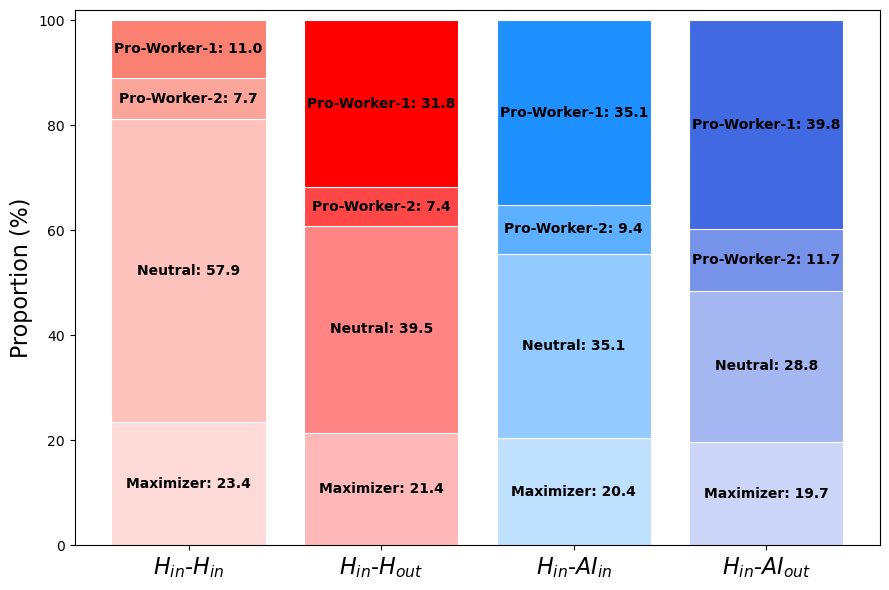

In [22]:
LOSS_CUT = 0.05
LOW, HIGH = 0.48, 0.52
cats = [
    "loss<0.05",
    "loss≥0.05 & 0.48≤share≤0.52",
    "loss≥0.05 & share>0.52",
    "loss≥0.05 & share<0.48",
]
cat_labels = ["Maximizer", "Neutral", "Pro-Worker-2", "Pro-Worker-1"]
def classify(loss, share):
    loss = pd.to_numeric(loss, errors="coerce")
    share = pd.to_numeric(share, errors="coerce")
    out = pd.Series(np.nan, index=loss.index, dtype="object")
    m_valid = loss.notna() & share.notna()
    m1 = m_valid & (loss <= LOSS_CUT)
    out[m1] = cats[0]
    m_ge = m_valid & (loss > LOSS_CUT)
    out[m_ge & (share < LOW)] = cats[3]
    out[m_ge & (share > HIGH)] = cats[2]
    out[m_ge & (share >= LOW) & (share <= HIGH)] = cats[1]
    return out
for i in [1, 2, 3, 4]:
    df[f"type_{i}"] = classify(df[f"loss_ratio_{i}"], df[f"task_share_type{i}"])
prop = (
    pd.DataFrame({
        "H_in-H_in":   df["type_1"].value_counts(normalize=True),
        "H_in-H_out":  df["type_2"].value_counts(normalize=True),
        "H_in-AI_in":  df["type_3"].value_counts(normalize=True),
        "H_in-AI_out": df["type_4"].value_counts(normalize=True),
    })
    .reindex(cats)
    .fillna(0.0)
)
# ── Color scheme: one base color per group with four shades ──
base_colors = ['salmon', 'red', 'dodgerblue', 'royalblue']  # H_in-H_in, H_in-H_out, H_in-AI_in, H_in-AI_out
# Shade factors from dark to light for categories 0-3
alpha_levels = [0.28, 0.48, 0.72, 1.0]
def make_shades(base, alphas):
    """Return shaded RGBA colors by blending a base color with white"""
    r, g, b, _ = to_rgba(base)
    shades = []
    for a in alphas:
        shades.append((r * a + 1 * (1 - a),
                       g * a + 1 * (1 - a),
                       b * a + 1 * (1 - a),
                       1.0))
    return shades
group_shades = [make_shades(bc, alpha_levels) for bc in base_colors]
labels = [r'$H_{in}$-$H_{in}$', r'$H_{in}$-$H_{out}$', r'$H_{in}$-$AI_{in}$', r'$H_{in}$-$AI_{out}$']
# ── Draw figure ──
fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(prop.shape[1])
bottom = np.zeros(prop.shape[1])
for k, cat in enumerate(cats):
    vals = prop.loc[cat].values*100
    bar_colors = [group_shades[j][k] for j in range(len(x))]
    bars = ax.bar(x, vals, bottom=bottom, color=bar_colors, width=0.8,
                  edgecolor="white", linewidth=0.8)
    for j, (bar, v) in enumerate(zip(bars, vals)):
        if v > 0.02:
            cy = bottom[j] + v / 2
            ax.text(bar.get_x() + bar.get_width() / 2, cy,
                    f"{cat_labels[k]}: {v:.1f}",
                    ha="center", va="center",
                    fontsize=10, fontweight="bold",
                    color="black")
        elif v > 0:
            cy = bottom[j] + v / 2
            ax.text(bar.get_x() + bar.get_width() / 2, cy,
                    f"{cat_labels[k]}: {v:.1f}",
                    ha="center", va="center",
                    fontsize=8, fontweight="bold",
                    color="black")
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=16)
ax.set_ylim(0, 102)
ax.set_ylabel("Proportion (%)", fontsize=16)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "Extended Data Fig.7(b).pdf")
plt.show()


### Extended Data Table 6(b)

In [23]:
# Define the category order and labels
category_order = [
    'loss≥0.05 & share<0.48',
    'loss≥0.05 & share>0.52',
    'loss≥0.05 & 0.48≤share≤0.52',
    'loss<0.05'
]
label_map = {
    'loss≥0.05 & share<0.48': 'Pro-Worker-1',
    'loss≥0.05 & share>0.52': 'Pro-Worker-2',
    'loss≥0.05 & 0.48≤share≤0.52': 'Neutral',
    'loss<0.05': 'Maximizer'
}
labels = ['Pro-Worker-1', 'Pro-Worker-2', 'Neutral', 'Maximizer']
# Convert to categorical with specified order
df['type_2_cat'] = pd.Categorical(df['type_2'], categories=category_order, ordered=True)
df['type_3_cat'] = pd.Categorical(df['type_3'], categories=category_order, ordered=True)
# Build the transition matrix (counts)
transition_counts = pd.crosstab(
    df['type_2_cat'], 
    df['type_3_cat'],
    dropna=False
)
# Convert to proportions (row-wise: each row sums to 1)
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)
# Rename index and columns
transition_matrix.index = labels
transition_matrix.columns = labels
transition_counts.index = labels
transition_counts.columns = labels
print("=== Transition Matrix (Counts) ===")
print(transition_counts)
print("\n=== Transition Matrix (Proportions) ===")
print(transition_matrix.round(4))


=== Transition Matrix (Counts) ===
              Pro-Worker-1  Pro-Worker-2  Neutral  Maximizer
Pro-Worker-1            66             4       22          3
Pro-Worker-2             6             6        8          2
Neutral                 26            17       71          4
Maximizer                7             1        4         52

=== Transition Matrix (Proportions) ===
              Pro-Worker-1  Pro-Worker-2  Neutral  Maximizer
Pro-Worker-1        0.6947        0.0421   0.2316     0.0316
Pro-Worker-2        0.2727        0.2727   0.3636     0.0909
Neutral             0.2203        0.1441   0.6017     0.0339
Maximizer           0.1094        0.0156   0.0625     0.8125


In [24]:
# Define the category order and labels
category_order = [
    'loss≥0.05 & share<0.48',
    'loss≥0.05 & share>0.52',
    'loss≥0.05 & 0.48≤share≤0.52',
    'loss<0.05'
]
label_map = {
    'loss≥0.05 & share<0.48': 'Pro-Worker-1',
    'loss≥0.05 & share>0.52': 'Pro-Worker-2',
    'loss≥0.05 & 0.48≤share≤0.52': 'Neutral',
    'loss<0.05': 'Maximizer'
}
labels = ['Pro-Worker-1', 'Pro-Worker-2', 'Neutral', 'Maximizer']
# Convert to categorical with specified order
df['type_2_cat'] = pd.Categorical(df['type_2'], categories=category_order, ordered=True)
df['type_4_cat'] = pd.Categorical(df['type_4'], categories=category_order, ordered=True)
# Build the transition matrix (counts)
transition_counts = pd.crosstab(
    df['type_2_cat'], 
    df['type_4_cat'],
    dropna=False
)
# Convert to proportions (row-wise: each row sums to 1)
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)
# Rename index and columns
transition_matrix.index = labels
transition_matrix.columns = labels
transition_counts.index = labels
transition_counts.columns = labels
print("=== Transition Matrix (Counts) ===")
print(transition_counts)
print("\n=== Transition Matrix (Proportions) ===")
print(transition_matrix.round(4))


=== Transition Matrix (Counts) ===
              Pro-Worker-1  Pro-Worker-2  Neutral  Maximizer
Pro-Worker-1            81             4        8          2
Pro-Worker-2             4             8       10          0
Neutral                 28            19       65          6
Maximizer                6             4        3         51

=== Transition Matrix (Proportions) ===
              Pro-Worker-1  Pro-Worker-2  Neutral  Maximizer
Pro-Worker-1        0.8526        0.0421   0.0842     0.0211
Pro-Worker-2        0.1818        0.3636   0.4545     0.0000
Neutral             0.2373        0.1610   0.5508     0.0508
Maximizer           0.0938        0.0625   0.0469     0.7969


In [25]:
# ----------------------------------------------------------------------
# 1. Basic setup
# ----------------------------------------------------------------------
CATEGORY_ORDER = [
    'loss≥0.05 & share<0.48',
    'loss≥0.05 & share>0.52',
    'loss≥0.05 & 0.48≤share≤0.52',
    'loss<0.05',
]
LABELS = ['Pro-Worker-1', 'Pro-Worker-2', 'Neutral', 'Maximizer']
# ----------------------------------------------------------------------
# 2. Compute transition matrices: counts and row proportions
# ----------------------------------------------------------------------
def compute_transition(df, from_col, to_col,
                       order=CATEGORY_ORDER, labels=LABELS):
    """Return (counts, row-proportions) transition matrices with nice labels."""
    f = pd.Categorical(df[from_col], categories=order, ordered=True)
    t = pd.Categorical(df[to_col],   categories=order, ordered=True)
    counts = pd.crosstab(f, t, dropna=False)
    counts = counts.reindex(index=order, columns=order, fill_value=0)
    props  = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    counts.index = counts.columns = labels
    props.index  = props.columns  = labels
    return counts, props
counts_23, props_23 = compute_transition(df, 'type_2', 'type_3')
counts_24, props_24 = compute_transition(df, 'type_2', 'type_4')
print("=== H_in-H_out => H_in-AI_in (Counts) ===")
print(counts_23)
print("\n=== H_in-H_out => H_in-AI_out (Counts) ===")
print(counts_24)
# ----------------------------------------------------------------------
# 3. Create the LaTeX table
# ----------------------------------------------------------------------
def fmt_cell(n, p, bold=False):
    """Format one cell as 'n (xx.x%)', optionally bold."""
    pct = f"{p*100:.1f}\\%" if p > 0 else "0\\%"
    cell = f"{n} ({pct})"
    return f"\\textbf{{{cell}}}" if bold else cell
def make_latex_table(counts_left, props_left, counts_right, props_right,
                     labels=LABELS,
                     panel_title="Panel (a): Minimal Group Experiment",
                     bold_cells_left=None, bold_cells_right=None,
                     caption="Extended Data Table 6 $\\vert$ Transition of Behavioral Types",
                     label="tab:transition_types"):
    """
    bold_cells_* : set of (row_label, col_label) tuples to print in bold,
                   e.g. {('Pro-Worker-1', 'Pro-Worker-1')}.
    """
    bold_cells_left  = bold_cells_left  or set()
    bold_cells_right = bold_cells_right or set()
    k = len(labels)
    lines = []
    lines.append("\\begin{table}[htbp]")
    lines.append("\\centering")
    lines.append(f"\\caption{{\\textbf{{{caption}}}}}")
    lines.append(f"\\label{{{label}}}")
    lines.append("\\small")
    lines.append("\\setlength{\\tabcolsep}{4pt}")
    lines.append("\\begin{tabular}{l" + "c" * (2 * k) + "}")
    lines.append("\\toprule\\toprule")
    span_l = ("$\\mathbf{H_{in}}$-$\\mathbf{H_{out}} \\Rightarrow "
              "\\mathbf{H_{in}}$-$\\mathbf{AI_{in}}$")
    span_r = ("$\\mathbf{H_{in}}$-$\\mathbf{H_{out}} \\Rightarrow "
              "\\mathbf{H_{in}}$-$\\mathbf{AI_{out}}$")
    lines.append(f" & \\multicolumn{{{k}}}{{c}}{{{span_l}}} "
                 f"& \\multicolumn{{{k}}}{{c}}{{{span_r}}} \\\\")
    lines.append(f"\\cmidrule(lr){{2-{k+1}}} \\cmidrule(lr){{{k+2}-{2*k+1}}}")
    # ---- Column-name row ----
    header = " & " + " & ".join(labels) + " & " + " & ".join(labels) + " \\\\"
    lines.append(header)
    lines.append("\\midrule")
    # ---- Panel title ----
    lines.append(f"\\multicolumn{{{2*k+1}}}{{l}}{{\\emph{{{panel_title}}}}} \\\\")
    # ---- Data rows ----
    for r in labels:
        row = [f"\\quad {r}"]
        for c in labels:
            row.append(fmt_cell(counts_left.loc[r, c], props_left.loc[r, c],
                                bold=(r, c) in bold_cells_left))
        for c in labels:
            row.append(fmt_cell(counts_right.loc[r, c], props_right.loc[r, c],
                                bold=(r, c) in bold_cells_right))
        lines.append(" & ".join(row) + " \\\\")
    lines.append("\\bottomrule\\bottomrule")
    lines.append("\\end{tabular}")
    lines.append("\\end{table}")
    return "\n".join(lines)
bold_l = {('Pro-Worker-1', 'Pro-Worker-1')}
bold_r = {('Pro-Worker-1', 'Pro-Worker-1')}
# bold_l = bold_r = {(lab, lab) for lab in LABELS}
latex_code = make_latex_table(counts_23, props_23, counts_24, props_24,
                              bold_cells_left=bold_l, bold_cells_right=bold_r)
print(latex_code)
with open(RESULTS_DIR / "Extended Data Table 6(b).tex", "w", encoding="utf-8") as f:
    f.write(latex_code)


=== H_in-H_out => H_in-AI_in (Counts) ===
              Pro-Worker-1  Pro-Worker-2  Neutral  Maximizer
Pro-Worker-1            66             4       22          3
Pro-Worker-2             6             6        8          2
Neutral                 26            17       71          4
Maximizer                7             1        4         52

=== H_in-H_out => H_in-AI_out (Counts) ===
              Pro-Worker-1  Pro-Worker-2  Neutral  Maximizer
Pro-Worker-1            81             4        8          2
Pro-Worker-2             4             8       10          0
Neutral                 28            19       65          6
Maximizer                6             4        3         51
\begin{table}[htbp]
\centering
\caption{\textbf{Extended Data Table 6 $\vert$ Transition of Behavioral Types}}
\label{tab:transition_types}
\small
\setlength{\tabcolsep}{4pt}
\begin{tabular}{lcccccccc}
\toprule\toprule
 & \multicolumn{4}{c}{$\mathbf{H_{in}}$-$\mathbf{H_{out}} \Rightarrow \mathbf{H_{in}}

## Regression Data

In [26]:
df['IOS_Human_same'] = df["Answer 10"].astype(int)
df['IOS_Human_different'] = df["Answer 11"].astype(int)
df['IOS_AI_same'] = df["Answer 12"].astype(int)
df['IOS_AI_different'] = df["Answer 13"].astype(int)
df["diff_IOS_Human_different"] = df["IOS_Human_different"] -df["IOS_Human_same"]
df["diff_IOS_AI_same"] =  df["IOS_AI_same"] - df["IOS_Human_same"]
df["diff_IOS_AI_different"] = df["IOS_AI_different"] - df["IOS_Human_same"]
df[["IOS_Human_same","IOS_Human_different","IOS_AI_same","IOS_AI_different"]].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
IOS_Human_same,299.0,4.672,1.601,1.0,4.0,5.0,6.0,7.0
IOS_Human_different,299.0,2.274,1.302,1.0,1.0,2.0,3.0,7.0
IOS_AI_same,299.0,2.886,1.742,1.0,1.0,3.0,4.0,7.0
IOS_AI_different,299.0,1.666,1.196,1.0,1.0,1.0,2.0,7.0


In [27]:
mapping = {
    "Strongly dislike": 1,
    "Dislike": 2,
    "Somewhat dislike": 3,
    "Neutral": 4,
    "Somewhat like": 5,
    "Like": 6,
    "Strongly like": 7
}
# 2. Split into four parts
parts = df["Answer 36"].str.split(r"\s*,\s*", expand=True)
parts.columns = ["Hs_like", "Hd_like", "AIs_like", "AId_like"]
# 3. Extract the text after the dash in each part
for col in parts.columns:
    parts[col] = parts[col].str.extract(r"-(.*)$")[0].str.strip()
    # Map to a 1-7 scale
    parts[col] = parts[col].map(mapping)
# 4. Merge back into df and create four new columns
df[["Hs_like", "Hd_like", "AIs_like", "AId_like"]] = parts
df[["Hs_like", "Hd_like", "AIs_like", "AId_like"]].describe().round(3)

,Hs_like,Hd_like,AIs_like,AId_like
count,299.000,299.000,299.000,299.000
mean,5.756,3.505,4.445,3.144
std,1.157,1.674,1.691,1.666
min,1.000,1.000,1.000,1.000
25%,5.000,2.000,4.000,1.500
50%,6.000,4.000,4.000,4.000
75%,7.000,5.000,6.000,4.000
max,7.000,7.000,7.000,7.000


In [28]:
mapping = {
    "Do not care at all": 1,
    "Mostly do not care": 2,
    "Slightly do not care": 3,
    "Neutral": 4,
    "Slightly care": 5,
    "Mostly care": 6,
    "Care very much": 7
}
# 2. Split into four parts
parts = df["Answer 37"].str.split(r"\s*,\s*", expand=True)
parts.columns = ["Hs_care", "Hd_care", "AIs_care", "AId_care"]
# 3. Extract the text after the dash in each part
for col in parts.columns:
    parts[col] = parts[col].str.extract(r"-(.*)$")[0].str.strip()
    # Map to a 1-7 scale
    parts[col] = parts[col].map(mapping)
# 4. Merge back into df and create four new columns
df[["Hs_care", "Hd_care", "AIs_care", "AId_care"]] = parts
df[["Hs_care", "Hd_care", "AIs_care", "AId_care"]].describe().round(3)

,Hs_care,Hd_care,AIs_care,AId_care
count,299.000,299.000,299.000,299.000
mean,5.679,4.114,3.084,2.508
std,1.312,1.965,2.002,1.773
min,1.000,1.000,1.000,1.000
25%,5.000,3.000,1.000,1.000
50%,6.000,4.000,3.000,2.000
75%,7.000,6.000,5.000,4.000
max,7.000,7.000,7.000,7.000


In [29]:
df['use AI at work'] = df['Answer 26'].map({'Yes': 1, 'No': 0})
df['use AI out of work'] = df['Answer 30'].map({'Yes': 1, 'No': 0})

In [30]:
# Answer 27 -> AI_days1
df["AI_days1"] = pd.to_numeric(df["Answer 27"], errors="coerce").fillna(0)
# Answer 31 -> AI_days2
df["AI_days2"] = pd.to_numeric(df["Answer 31"], errors="coerce").fillna(0)
df["AI_days_total"] = df["AI_days1"] + df["AI_days2"]

In [31]:
mapping = {
    '0-15 Minutes / Day': 1,
    '15-59 Minutes / Day': 2,
    '60+ Minutes / Day': 3
}
df["AI_hours1"] = df["Answer 28"].map(mapping).fillna(0).astype(int)
df["AI_hours2"] = df["Answer 32"].map(mapping).fillna(0).astype(int)
df["AI_hours_total"] = df["AI_hours1"] + df["AI_hours2"]

In [32]:
# Split Answer 27 and Answer 30 into four columns
df[['Answer 29_1', 'Answer 29_2', 'Answer 29_3', 'Answer 29_4']] = \
    df['Answer 29'].str.split('|', expand=True)
df[['Answer 33_1', 'Answer 33_2', 'Answer 33_3', 'Answer 33_4']] = \
    df['Answer 33'].str.split('|', expand=True)
# Mapping dictionary
mapping = {
    'Strongly disagree': 1,
    'Disagree': 2,
    'Somewhat disagree': 3,
    'Neutral': 4,
    'Somewhat agree': 5,
    'Agree': 6,
    'Strongly agree': 7
}
# Map values and fill missing values with 1
cols_29 = ['Answer 29_1', 'Answer 29_2', 'Answer 29_3', 'Answer 29_4']
cols_33 = ['Answer 33_1', 'Answer 33_2', 'Answer 33_3', 'Answer 33_4']
df[cols_29] = df[cols_29].apply(lambda s: s.map(mapping).fillna(1))
df[cols_33] = df[cols_33].apply(lambda s: s.map(mapping).fillna(1))
# Compute scores
df['Improvement_scores1'] = df[cols_29].sum(axis=1)
df['Improvement_scores2'] = df[cols_33].sum(axis=1)
df['Improvement_scores'] = (df['Improvement_scores1'] + df['Improvement_scores2']) / 2
df['Improvement_scores'].describe().round(3)

count    299.000
mean      16.261
std        6.706
min        4.000
25%       11.500
50%       17.500
75%       21.250
max       28.000
Name: Improvement_scores, dtype: float64

In [33]:
df['Functional_Tool'] = df['Answer 34'].str.contains('A Functional Tool', na=False).astype(int)
df['Smart_Assistant'] = df['Answer 34'].str.contains('A Smart Assistant', na=False).astype(int)
df['Collaborative_Partner'] = df['Answer 34'].str.contains('A Collaborative Partner', na=False).astype(int)
df['Knowledge_Consultant'] = df['Answer 34'].str.contains('A Knowledge Consultant', na=False).astype(int)
df['Social_Companion'] = df['Answer 34'].str.contains('A Social Companion', na=False).astype(int)
df['Big_Tech'] = df['Answer 34'].str.contains('A Big Tech', na=False).astype(int)
df['Potential_Risk_Threat'] = df['Answer 34'].str.contains('A Potential Risk or Threat', na=False).astype(int)
df['Not_Use_GenAI'] = df['Answer 34'].str.contains('I do not use Generative AI', na=False).astype(int)
df['Other_Use'] = df['Answer 34'].str.contains('Other', na=False).astype(int)
# Inspect variable distributions
print("Frequency counts by category:")
for cat in ['Functional_Tool', 'Smart_Assistant', 'Collaborative_Partner', 
            'Knowledge_Consultant', 'Social_Companion', 'Big_Tech', 
            'Potential_Risk_Threat', 'Not_Use_GenAI', 'Other_Use']:
    print(f"{cat}: {df[cat].sum()}")


Frequency counts by category:
Functional_Tool: 200
Smart_Assistant: 149
Collaborative_Partner: 67
Knowledge_Consultant: 159
Social_Companion: 37
Big_Tech: 27
Potential_Risk_Threat: 26
Not_Use_GenAI: 34
Other_Use: 5


In [34]:
# Define seven category variables
categories = [
    'Writing',
    'Practical Guidance',
    'Technical Help',
    'Seeking Information',
    'Multimedia',
    'Expression and Interaction',
    'Other/Unknown'
]
df['Writing'] = df['Answer 35'].str.contains('Writing', na=False).astype(int)
df['Practical Guidance'] = df['Answer 35'].str.contains('Practical Guidance', na=False).astype(int)
df['Technical Help'] = df['Answer 35'].str.contains('Technical Help', na=False).astype(int)
df['Seeking Information'] = df['Answer 35'].str.contains('Seeking Information', na=False).astype(int)
df['Multimedia'] = df['Answer 35'].str.contains('Multimedia', na=False).astype(int)
df['Expression and Interaction'] = df['Answer 35'].str.contains('Expression and Interaction', na=False).astype(int)
df['Other_Relations'] = df['Answer 35'].str.contains('Other/Unknown', na=False).astype(int)
print("Frequency counts by category:")
for cat in ['Writing', 'Practical Guidance', 'Technical Help', 'Seeking Information', 'Multimedia', 'Expression and Interaction', 'Other_Relations']:
    print(f"{cat}: {df[cat].sum()}")


Frequency counts by category:
Writing: 151
Practical Guidance: 151
Technical Help: 144
Seeking Information: 232
Multimedia: 77
Expression and Interaction: 47
Other_Relations: 51


In [35]:
# 1. Identify columns to reshape
value_cols = [c for c in df.columns if re.match(r'.* (Task|Revenue) \d+$', c)]
ratio_cols = [c for c in df.columns if re.match(r'^ratio \d+$', c)]
corner_cols = [c for c in df.columns if re.match(r'^Corner \d+$', c)]
# 2. Process X/Y task and revenue columns
long_df = df.melt(
    id_vars=["Prolific ID"],
    value_vars=value_cols,
    var_name="variable",
    value_name="value"
)
long_df[["cond_xy", "kind", "k"]] = long_df["variable"].str.extract(r'^(X|Y)\s+(Task|Revenue)\s+(\d+)$')
long_df["k"] = long_df["k"].astype(int)
# 3. Process ratio columns
ratio_long = df.melt(
    id_vars=["Prolific ID"],
    value_vars=ratio_cols,
    var_name="variable",
    value_name="ratio"
)
ratio_long["k"] = ratio_long["variable"].str.extract(r'^ratio\s+(\d+)$').astype(int)
ratio_long = ratio_long[["Prolific ID", "k", "ratio"]]
# 4. Process Corner columns
corner_long = df.melt(
    id_vars=["Prolific ID"],
    value_vars=corner_cols,
    var_name="variable",
    value_name="Corner"
)
corner_long["k"] = corner_long["variable"].str.extract(r'^Corner\s+(\d+)$').astype(int)
corner_long = corner_long[["Prolific ID", "k", "Corner"]]
# 5. Create condition and round variables
long_df["condition"] = ((long_df["k"] - 1) // 22 + 1)
long_df["round"] = (long_df["k"] - 1) % 22 + 1
# 6. Pivot X/Y task and revenue into four columns
long_df["xy_kind"] = long_df["cond_xy"] + " " + long_df["kind"]
wide_df = long_df.pivot_table(
    index=["Prolific ID", "condition", "round", "k"],
    columns="xy_kind",
    values="value",
    aggfunc="first"
).reset_index()
# 7. Merge ratio and Corner variables
wide_df = wide_df.merge(ratio_long, on=["Prolific ID", "k"], how="left")
wide_df = wide_df.merge(corner_long, on=["Prolific ID", "k"], how="left")
# 8. Order columns and drop k if unused
cols_order = ["Prolific ID", "condition", "round", 
              "X Task", "Y Task", "X Revenue", "Y Revenue", 
              "ratio", "Corner"]
wide_df = wide_df[[c for c in cols_order if c in wide_df.columns]]
print(wide_df.head())


                Prolific ID  condition  round  X Task  Y Task  X Revenue  \
0  558ffe16fdf99b3f7aada34d          1      1   100.0     0.0       1.00   
1  558ffe16fdf99b3f7aada34d          1      2     0.0   100.0       0.20   
2  558ffe16fdf99b3f7aada34d          1      3   100.0     0.0       0.62   
3  558ffe16fdf99b3f7aada34d          1      4   100.0     0.0       0.99   
4  558ffe16fdf99b3f7aada34d          1      5    50.0    50.0       0.80   

   Y Revenue  ratio  Corner  
0       0.35    0.0     NaN  
1       0.80    0.0     NaN  
2       0.59    0.0     NaN  
3       0.67    0.0     NaN  
4       0.80    NaN     NaN  


In [36]:
result_df=df[["Prolific ID","task_share1","task_share2","task_share3","task_share4",'IOS_Human_same', 'IOS_Human_different', 'IOS_AI_same', 'IOS_AI_different',"Hs_like", "Hd_like", "AIs_like", "AId_like",
    "Hs_care", "Hd_care", "AIs_care", "AId_care","Improvement_scores1","Improvement_scores2",
    'Writing', 'Practical Guidance', 'Technical Help', 'Seeking Information', 'Multimedia', 'Expression and Interaction', 'Other_Use',
    'Functional_Tool', 'Smart_Assistant', 'Collaborative_Partner', 'Knowledge_Consultant', 'Social_Companion', 'Big_Tech', 'Potential_Risk_Threat', 'Not_Use_GenAI', 'Other_Relations',"use AI at work","use AI out of work",
    'AI_days1',"AI_days2","AI_hours1","AI_hours2"]].copy()
wide_df=wide_df.merge(result_df, on="Prolific ID", how="left")
wide_df.to_csv(RESULTS_DIR / "regress_data_wide_political.csv", index=False)

## Demographic

### Extended Data Table 2: Political

In [37]:
df["male"] = ((df["Answer 15"] == "Male")).astype(int)
df["male"].mean()
df["female"] = ((df["Answer 15"] == "Female")).astype(int)
df["female"].mean()
df["male"].mean()

0.47491638795986624

In [38]:
df["age"]=2025-df["Answer 14"].astype(int)
bins = [0, 24, 54, float('inf')]
labels = ['≤24', '25-54', '≥55']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)
# Compute proportions
age_distribution = df['age_group'].value_counts(normalize=True).sort_index() * 100
print(age_distribution.round(2))
df["age"].mean().round(2)

age_group
≤24      12.37
25-54    50.84
≥55      36.79
Name: proportion, dtype: float64


45.44

In [39]:
df["low_edu"]=(df["Answer 18"].str.contains("High school|Some high", na=False)).astype(int)
df["mid_edu"]=(df["Answer 18"].str.contains("Associates or technical degree|Bachelor|college", na=False)).astype(int)
df["high_edu"]=(df["Answer 18"].str.contains("Graduate or professional degrees", na=False)).astype(int)
df[["low_edu","mid_edu","high_edu"]].mean().round(3)

low_edu     0.154
mid_edu     0.662
high_edu    0.181
dtype: float64

In [40]:
white_proportion = df["Answer 16"].str.contains("White", na=False).mean()
print(f"Share containing 'White': {white_proportion:.2%}")
minority_proportion = 1 - white_proportion
print(f"Minority share: {minority_proportion:.2%}")
# Create a minority indicator
df["minority"] = (~df["Answer 16"].str.contains("White", na=False)).astype(int)


Share containing 'White': 76.59%
Minority share: 23.41%


In [41]:
df["religious"] = (~(df["Answer 17"] == "I am not religious")).astype(int)
df["religious"].mean()

0.6020066889632107

In [42]:
df["low_income"]=(df["Answer 19"].str.contains("25,000", na=False)).astype(int)
df["mid_income"]=(df["Answer 19"].str.contains("74,999|99,999", na=False)).astype(int)
df["high_income"]=(df["Answer 19"].str.contains("100,000|150,000", na=False)).astype(int)
df[["low_income","mid_income","high_income"]].mean().round(3)

low_income     0.341
mid_income     0.375
high_income    0.274
dtype: float64

In [43]:
df["employed"]=(df["Answer 20"].str.contains("Working full-time|Working part-time", na=False)).astype(int)
df["work_age"]=2025-df["Answer 23"].astype(float)
df["boss"] = ((df["Answer 21"] == "Yes")).astype(int)
df[["employed","work_age","boss"]].mean().round(3)


employed     0.692
work_age    10.812
boss         0.314
dtype: float64

In [44]:
df['democrat'] = df['Answer 1'].str.contains('Democrat', na=False).astype(int)
df['republic'] = df['Answer 1'].str.contains('Republican', na=False).astype(int)
df['ind'] = df['Answer 1'].str.contains('Independent', na=False).astype(int)
df[['democrat','republic','ind']].mean().round(3)

democrat    0.458
republic    0.244
ind         0.261
dtype: float64